# Machine Learning I
# Aprendizado Supervisionado
## Arvore de Decisao com dataset_treino

Notebook baseado no exemplo de aula, adaptado para o conjunto `dataset_treino.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split as tts
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import accuracy_score as acc_score
from sklearn.metrics import confusion_matrix as cm
from sklearn.metrics import ConfusionMatrixDisplay as CMD

In [2]:
# carga de dados
candidatos = [
    Path('dataset_treino.csv'),
    Path('../dataset_treino.csv'),
    Path.cwd() / 'dataset_treino.csv',
    Path.cwd().parent / 'dataset_treino.csv',
]

for caminho in candidatos:
    if caminho.exists():
        DATASET_PATH = caminho
        break
else:
    raise FileNotFoundError('Nao encontrei dataset_treino.csv')

colunas = [f'pos_{i}' for i in range(1, 10)] + ['classe']
dados = pd.read_csv(DATASET_PATH, header=None, names=colunas)
dados.head()

,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,pos_7,pos_8,pos_9,classe
0,1,1,-1,-1,-1,1,1,-1,1,Empate
1,1,-1,1,-1,-1,1,0,0,1,Fim_X_Vence
2,0,0,0,-1,1,-1,1,1,-1,Possibilidade_fim
3,0,1,1,-1,-1,1,1,0,-1,Possibilidade_fim
4,0,0,0,0,-1,0,1,-1,1,Tem jogo


In [3]:
# separacao em features e target
X = dados.drop(columns='classe')
y = dados['classe']

print(X.shape)
print(y.shape)
print(y.value_counts())

(886, 9)
(886,)
classe
Fim_X_Vence          180
Possibilidade_fim    180
Tem jogo             180
Fim_O_Vence          180
Empate               166
Name: count, dtype: int64


In [4]:
# separacao em treino e teste, e X e y

treino_X, teste_X, treino_y, teste_y = tts(
    X,
    y,
    random_state=0,
    test_size=0.3,
    stratify=y
)

print(treino_X.shape)
print(treino_y.shape)
print(teste_X.shape)
print(teste_y.shape)
print(teste_y.value_counts())

(620, 9)
(620,)
(266, 9)
(266,)
classe
Tem jogo             54
Possibilidade_fim    54
Fim_X_Vence          54
Fim_O_Vence          54
Empate               50
Name: count, dtype: int64


Acuracia= 0.6353383458646616


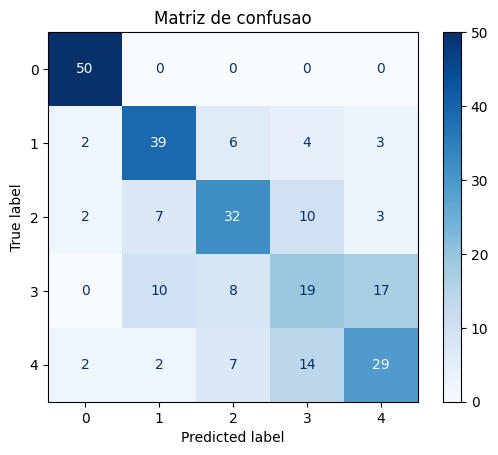

In [5]:
# inducao do modelo de classificacao por arvore de decisao
modelo = DTC(
    random_state=0,
    criterion='entropy',
    min_samples_split=2,
    min_samples_leaf=1,
    max_leaf_nodes=None,
    class_weight=None,
    ccp_alpha=0.0
)

modelo.fit(treino_X, treino_y)
teste_pred_y = modelo.predict(teste_X)
acuracia = acc_score(teste_y, teste_pred_y)
resultado = cm(teste_y, teste_pred_y)

print('Acuracia=', acuracia)
CMD(resultado).plot(cmap='Blues')
plt.title('Matriz de confusao')
plt.show()

In [6]:
# apresentacao do modelo
modelo_txt = export_text(modelo, feature_names=X.columns.tolist())
print(modelo_txt)

|--- pos_5 <= -0.50
|   |--- pos_2 <= 0.50
|   |   |--- pos_9 <= -0.50
|   |   |   |--- pos_2 <= -0.50
|   |   |   |   |--- pos_1 <= 0.00
|   |   |   |   |   |--- class: Fim_O_Vence
|   |   |   |   |--- pos_1 >  0.00
|   |   |   |   |   |--- pos_6 <= 0.00
|   |   |   |   |   |   |--- class: Fim_X_Vence
|   |   |   |   |   |--- pos_6 >  0.00
|   |   |   |   |   |   |--- class: Empate
|   |   |   |--- pos_2 >  -0.50
|   |   |   |   |--- pos_1 <= -0.50
|   |   |   |   |   |--- class: Fim_O_Vence
|   |   |   |   |--- pos_1 >  -0.50
|   |   |   |   |   |--- pos_6 <= 0.50
|   |   |   |   |   |   |--- pos_6 <= -0.50
|   |   |   |   |   |   |   |--- class: Possibilidade_fim
|   |   |   |   |   |   |--- pos_6 >  -0.50
|   |   |   |   |   |   |   |--- pos_7 <= 0.50
|   |   |   |   |   |   |   |   |--- class: Tem jogo
|   |   |   |   |   |   |   |--- pos_7 >  0.50
|   |   |   |   |   |   |   |   |--- class: Fim_X_Vence
|   |   |   |   |   |--- pos_6 >  0.50
|   |   |   |   |   |   |--- pos_7 <= -

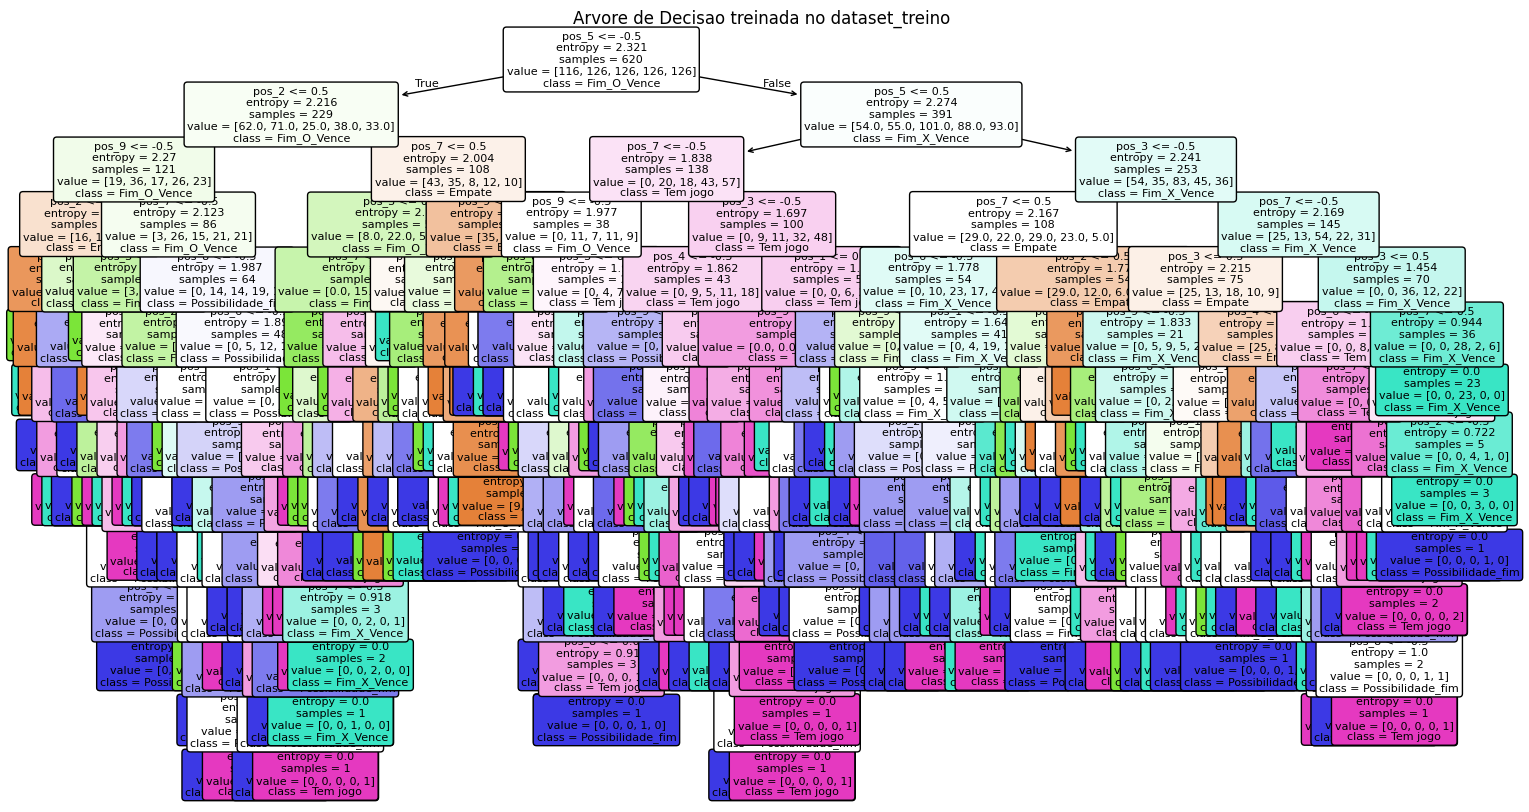

In [7]:
# visualizacao da arvore
plt.figure(figsize=(18, 10))
plot_tree(
    modelo,
    filled=True,
    rounded=True,
    feature_names=X.columns.tolist(),
    class_names=modelo.classes_,
    fontsize=8
)
plt.title('Arvore de Decisao treinada no dataset_treino')
plt.show()

In [9]:
# testes rapidos
assert not dados.isnull().any().any(), 'Dataset possui valores nulos'
assert len(treino_X) > 0 and len(teste_X) > 0, 'Divisao treino/teste invalida'
assert len(teste_pred_y) == len(teste_y), 'Quantidade de predicoes diferente do teste'
assert resultado.shape == (len(modelo.classes_), len(modelo.classes_)), 'Matriz de confusao com formato inesperado'
assert 0.0 <= acuracia <= 1.0, 'Acuracia fora do intervalo esperado'

print('Todos os testes passaram.')

Todos os testes passaram.
